# Biblioteka Matplotlib

Matplotlib to kompleksowa biblioteka służąca to tworzenia statycznych i animowanych wizualizacji w Pythonie. Umożliwia dostosowanie wykresów pod dowolne wymagania i zapisanie ich w wysokiej jakości.

In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
data = pd.read_csv("athlete_events_pd.csv")

--------------------
### Histogram

Histogram przedstawia rozłożenie różnych wartości w danej kategorii. Jego wygląd jest podobny do wykresu kolumnowego, jednak jego zastosowanie jest zupełnie inne i wykresy te nie powinny być ze sobą mylone.

##### ⭐ Zadanie 1: 

Przygotuj histogram (`hist`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `bins` i `range` oraz dobierz dla nich takie wartości, które wg. Ciebie najlepiej wizualizują dane. Dodatkowo, zapoznaj się z parametrem `density`. Zadbaj o czytelność wykresu (tytuł wykresu oraz podpisy osi). 

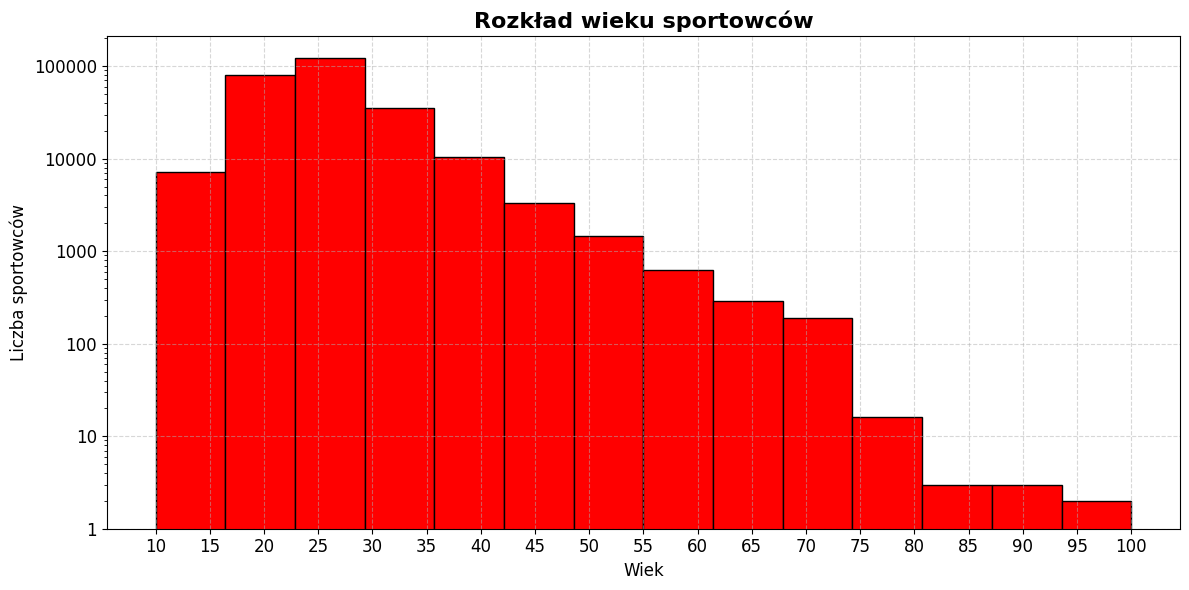

In [3]:
ages = data["Age"].dropna()
plt.figure(figsize=(12, 6))
plt.hist(ages, bins=14, range=(10, 100), density=False, color='red', edgecolor='black')
plt.yscale('log')
plt.title("Rozkład wieku sportowców", fontsize=16, weight='bold')
plt.xlabel("Wiek", fontsize=12)
plt.ylabel("Liczba sportowców", fontsize=12)
yticks = [1, 10, 100, 1_000, 10_000, 100_000]
plt.xticks(range(10, 101, 5), fontsize=12)
plt.yticks(yticks, [str(y) for y in yticks], fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### ⭐ Zadanie 2:

Przygotuj dwuwymiarowy histogram (`hist2d`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda). 

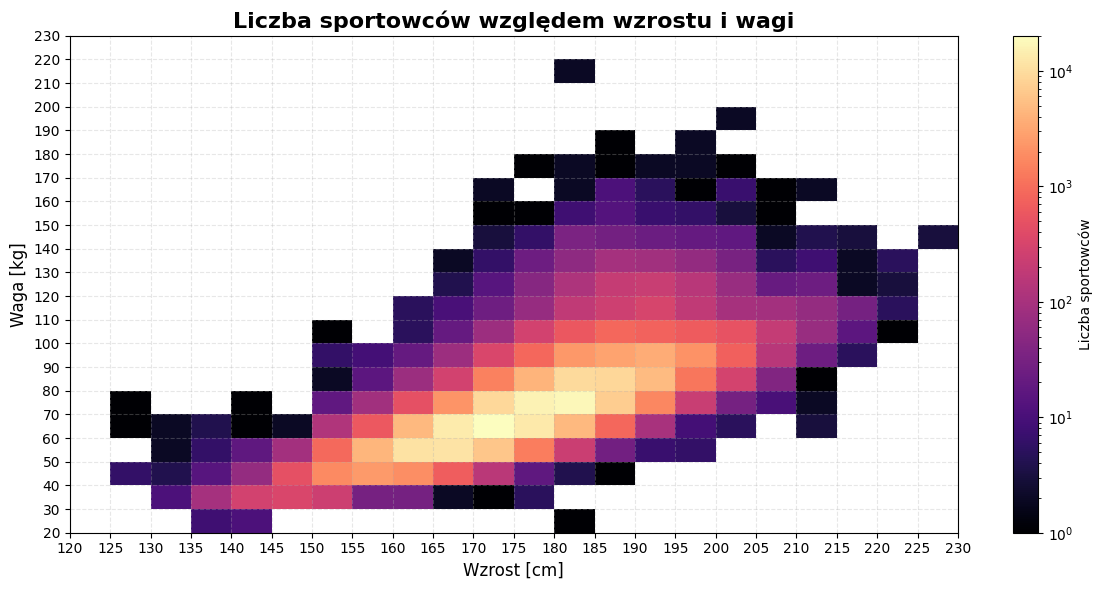

In [4]:
height_weight = data[["Height", "Weight"]].dropna()
plt.figure(figsize=(12, 6))
x_range = (120, 230)  
y_range = (20, 230)
hist = plt.hist2d( height_weight["Height"], height_weight["Weight"], bins=[22, 21], range=[x_range, y_range], cmap="magma", norm=LogNorm() )
plt.colorbar(label="Liczba sportowców")
plt.title("Liczba sportowców względem wzrostu i wagi", fontsize=16, weight='bold')
plt.xlabel("Wzrost [cm]", fontsize=12)
plt.ylabel("Waga [kg]", fontsize=12)
plt.xticks(range(120, 231, 5))
plt.yticks(range(20, 231, 10))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 3:

Przygotuj dwuwymiarowy histogram z heksagonami (`hexbin`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrem `gridsize` oraz dobierz dla niego taką wartość, która wg. Ciebie najlepiej wizualizuje dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda). 

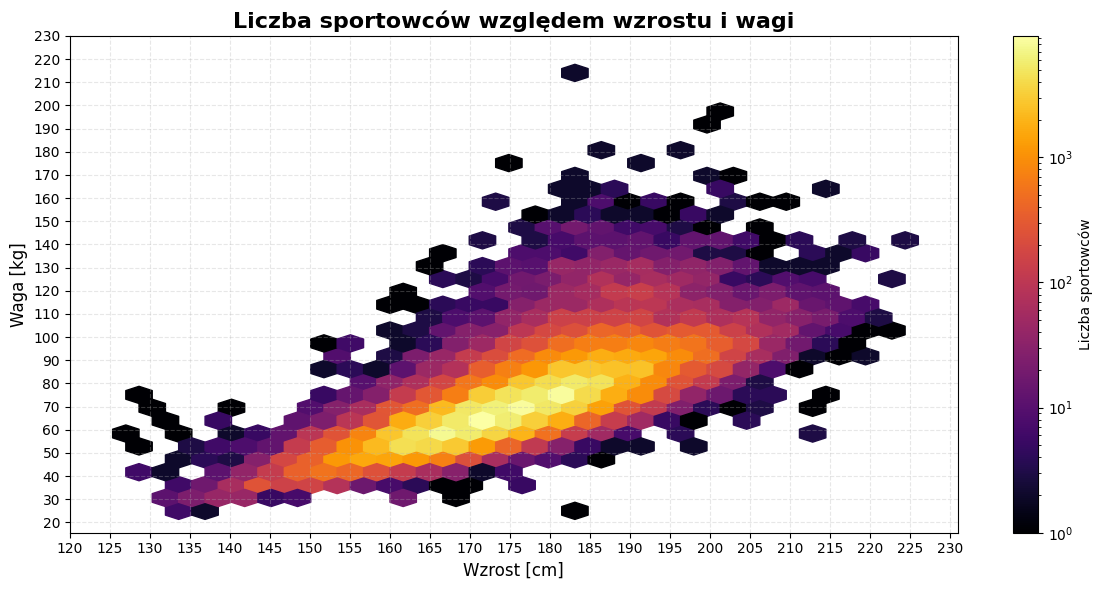

In [5]:

plt.figure(figsize=(12, 6)) 
x_range = (120, 230)  
y_range = (20, 230)
hist = plt.hexbin( height_weight["Height"], height_weight["Weight"], gridsize=30, cmap="inferno", norm=LogNorm() )
plt.colorbar(label="Liczba sportowców")
plt.title("Liczba sportowców względem wzrostu i wagi", fontsize=16, weight='bold')
plt.xlabel("Wzrost [cm]", fontsize=12)
plt.ylabel("Waga [kg]", fontsize=12)
plt.xticks(range(120, 231, 5))
plt.yticks(range(20, 231, 10))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

-------------------
### Wykres słupkowy i kolumnowy (skumulowany) 

Wykres kolumnowy i wykres słupkowy pokazuje jawne wartości dla pojedynczej lub dla wielu serii danych. Oś z wartościami liczbowymi powinna zaczynać się od 0, żeby uniknąć ukrytego przeskoku, który może dawać mylne złudzenie. Podpisy danych muszą być czytelne, zatem często są one umieszczone prostopadle do kolumn / słupków. <br/><br/>
Wykres kolumnowy lub słupkowy skumulowany dodatkowo rozróżnia kolejne serie danych, które są składnikami sumy końcowej dla wyświetlanych wartości. Serie danych najczęściej są rozróżniane kolorem, zatem do ich zrozumienia potrzebna jest legenda. 

##### ⭐ Zadanie 4:

Przygotuj wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrem `tick_label` i ustawieniami `xticks` oraz dobierz dla nich takie wartości, które wg. Ciebie najlepiej wizualizują dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz podpis dla każdej kolumny). 

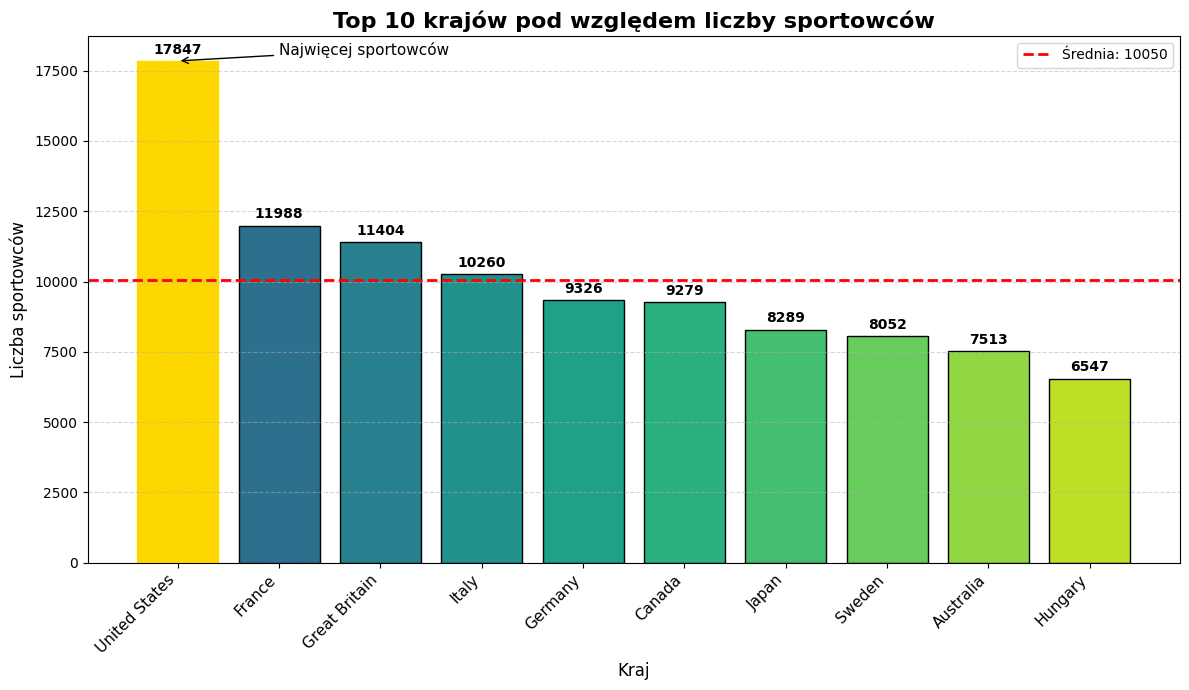

In [19]:
import numpy as np

top_teams = data["Team"].value_counts().head(10)
teams = top_teams.index
counts = top_teams.values
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(teams)))
bars = plt.bar(range(len(teams)), counts, color=colors, edgecolor='black')
bars[0].set_color("gold")
plt.bar_label(bars, padding=3, fontsize=10, fontweight='bold')
mean_val = np.mean(counts)
plt.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Średnia: {int(mean_val)}")

plt.annotate(
    "Najwięcej sportowców",
    xy=(0, counts[0]),
    xytext=(1, counts[0] + 200),
    arrowprops=dict(facecolor='black', arrowstyle="->"),
    fontsize=11
)

plt.xlabel("Kraj", fontsize=12)
plt.ylabel("Liczba sportowców", fontsize=12)
plt.title("Top 10 krajów pod względem liczby sportowców", fontsize=16, weight='bold')
plt.xticks(range(len(teams)), teams, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 5:

Przygotuj wykres słupkowy (`barh`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z funkcją `gca()` oraz ustawieniami `set_yticks` i `set_yticklabels`. Wykorzystaj je, żeby wyeliminować niestandardowe odstępy pomiędzy danymi. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz podpis dla każdego słupka). 

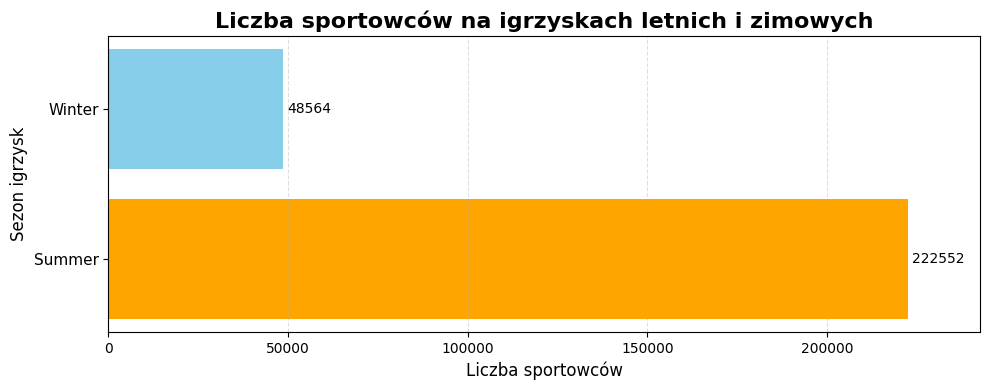

In [7]:
season_counts = data["Season"].value_counts()
labels = season_counts.index.tolist()     
values = season_counts.values.tolist()    
plt.figure(figsize=(10, 4))
bars = plt.barh(range(len(labels)), values, color=['orange', 'skyblue'])
ax = plt.gca()
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11)
plt.xlim(0, max(values) + 20000)
plt.xlabel("Liczba sportowców", fontsize=12)
plt.ylabel("Sezon igrzysk", fontsize=12)
plt.title("Liczba sportowców na igrzyskach letnich i zimowych", fontsize=16, weight='bold')
plt.bar_label(bars, padding=3, fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 6:

Przygotuj wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `width` oraz dobierz dla niego właściwą wartość mając na uwadze wizualizację określonej liczby serii danych. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i podpis dla każdej grupy kolumn oraz legenda). 

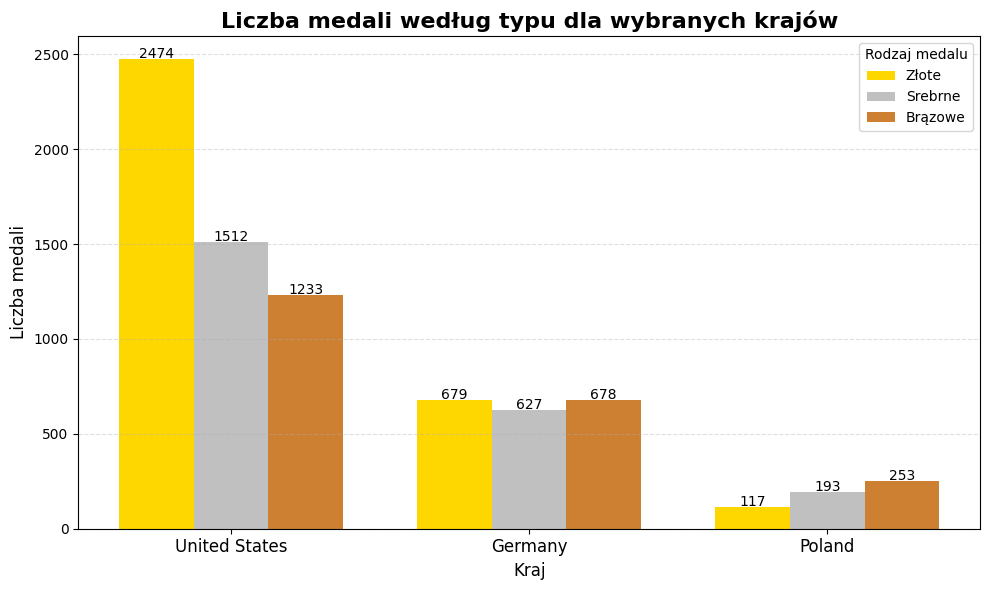

In [8]:
medals = data[data["Medal"].notna()]
countries = ['United States', 'Germany', 'Poland']
medal_types = ['Gold', 'Silver', 'Bronze']
medal_data = {
    medal: medals[medals["Medal"] == medal]["Team"].value_counts().reindex(countries, fill_value=0)
    for medal in medal_types
}
x = np.arange(len(countries))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, medal_data['Gold'], width, label='Złote', color='gold')
plt.bar(x, medal_data['Silver'], width, label='Srebrne', color='silver')
plt.bar(x + width, medal_data['Bronze'], width, label='Brązowe', color='#cd7f32')
plt.xlabel("Kraj", fontsize=12)
plt.ylabel("Liczba medali", fontsize=12)
plt.title("Liczba medali według typu dla wybranych krajów", fontsize=16, weight='bold')
plt.xticks(x, countries, fontsize=12)
plt.legend(title="Rodzaj medalu")
for i in range(len(countries)):
    plt.text(x[i] - width, medal_data['Gold'].iloc[i] + 5, str(medal_data['Gold'].iloc[i]), ha='center', fontsize=10)
    plt.text(x[i], medal_data['Silver'].iloc[i] + 5, str(medal_data['Silver'].iloc[i]), ha='center', fontsize=10)
    plt.text(x[i] + width, medal_data['Bronze'].iloc[i] + 5, str(medal_data['Bronze'].iloc[i]), ha='center', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 7:

Przygotuj wykres kolumnowy skumulowany (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `bottom` oraz dobierz dla niego właściwą wartość mając na uwadze wizualizację określonej liczby serii danych jako składników sumy. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i podpis dla każdej kolumn oraz legenda). 

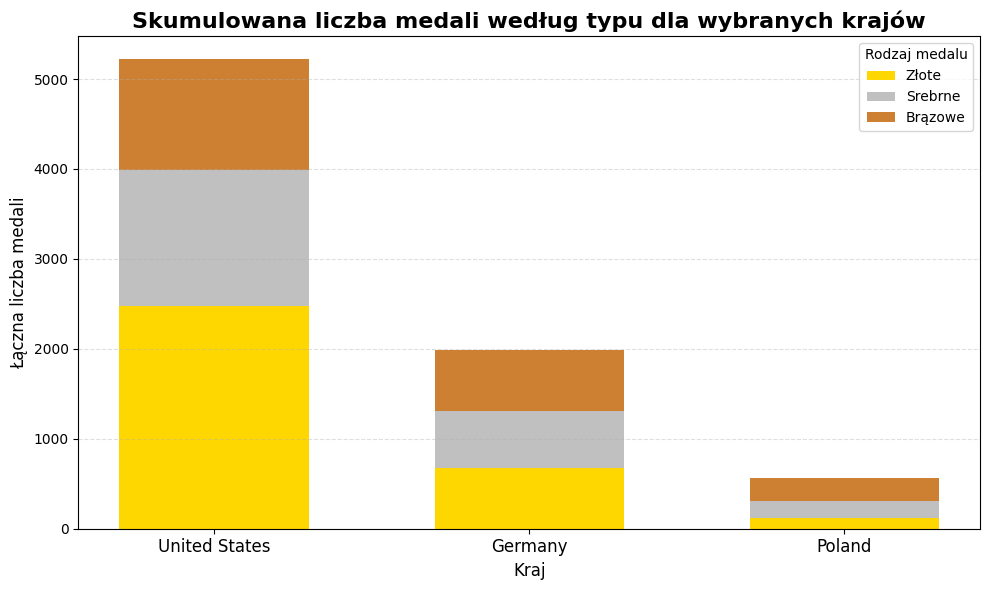

In [9]:
medals = data[data["Medal"].notna()]
countries = ['United States', 'Germany', 'Poland']
medal_types = ['Gold', 'Silver', 'Bronze']
medal_data = {
    medal: medals[medals["Medal"] == medal]["Team"].value_counts().reindex(countries, fill_value=0)
    for medal in medal_types
}
x = np.arange(len(countries))
width = 0.6 
plt.figure(figsize=(10, 6))
plt.bar(x, medal_data['Gold'], width, label='Złote', color='gold')
plt.bar(x, medal_data['Silver'], width, bottom=medal_data['Gold'], label='Srebrne', color='silver')
plt.bar(x, medal_data['Bronze'], width, bottom=medal_data['Gold'] + medal_data['Silver'], label='Brązowe', color='#cd7f32')
plt.xlabel("Kraj", fontsize=12)
plt.ylabel("Łączna liczba medali", fontsize=12)
plt.title("Skumulowana liczba medali według typu dla wybranych krajów", fontsize=16, weight='bold')
plt.xticks(x, countries, fontsize=12)
plt.legend(title="Rodzaj medalu")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

-------------------
### Wykres kołowy

Wykres kołowy przedstawia zależność pomiędzy obiektami, które są częścią całości. Każdy wycinek koła reprezentuje część składową obiektu. Dobrym zwyczajem jest umieszczanie wycinków w kolejności rosnącej lub malejącej, a nie losowej.

##### ⭐ Zadanie 8:

Przygotuj wykres kołowy (`pie`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `normalize`, `explode` oraz `autopct`, `pctdistance`, `labels`, `labeldistance` i dobierz dla nich właściwe wartości, które wg. Ciebie najlepiej wizualizują dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpis i wartość procentowa dla każdej części koła). 

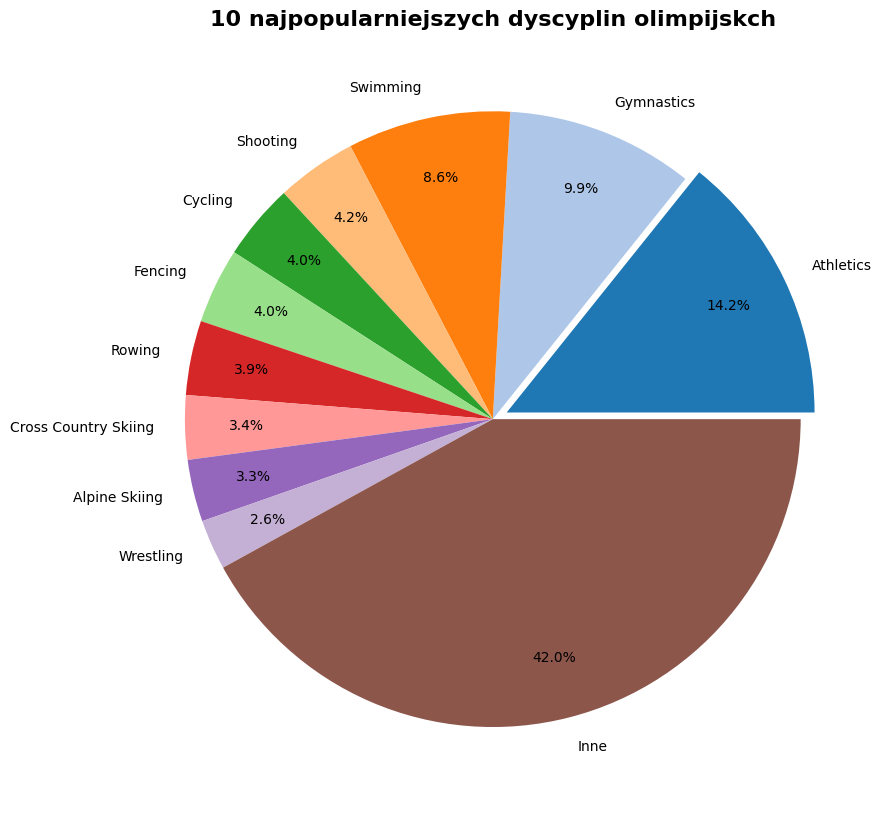

In [10]:
sport_counts = data["Sport"].value_counts()
top_sports = sport_counts.head(10)
others = sport_counts[10:].sum()
sports = pd.concat([top_sports, pd.Series({"Inne": others})])
labels = sports.index
sizes = sports.values
colors = plt.cm.tab20.colors[:len(labels)] 
explode = [0.05] + [0] * (len(labels) - 1)
plt.figure(figsize=(9, 9))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', explode=explode, startangle=360, colors=colors, pctdistance=0.8, labeldistance=1.1, normalize=True)
plt.title("10 najpopularniejszych dyscyplin olimpijskch", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 9:

Przygotuj wykres kołowy (`pie`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zastosuj co najmniej 3 serie danych i podziel te informacje na osobne podwykresy (`subplot`) jednego obrazu. Zapoznaj się z obiektami `figure` i `axes`. Zadbaj o czytelność wykresu (tytuł obrazu i każdego wykresu, podpis i wartość procentowa dla każdej części koła). 

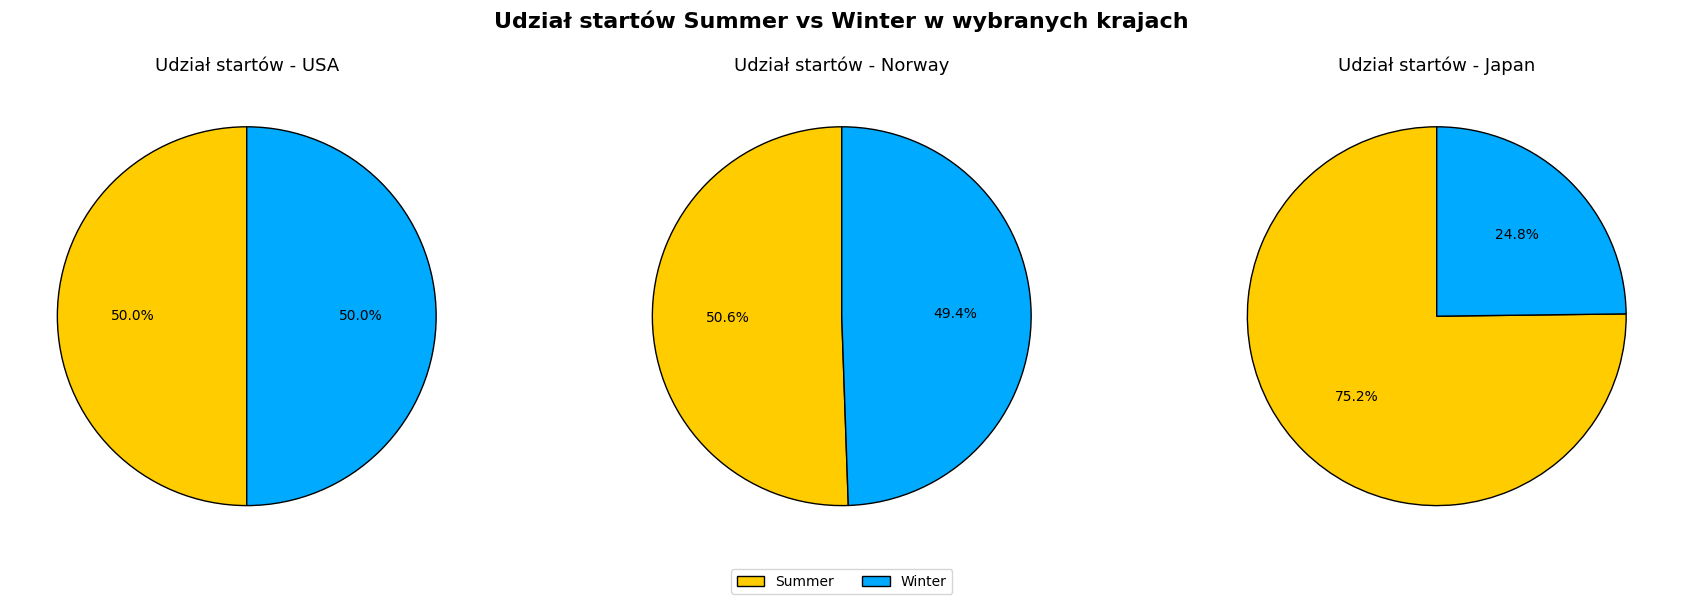

In [11]:
subset = data[data["Season"].notna()]
countries = ['USA', 'Norway', 'Japan']
categories = ['Summer', 'Winter']
colors = ['#ffcc00', '#00aaff']
figure, axes = plt.subplots(1, 3, figsize=(18, 6))
all_wedges = None
for i, country in enumerate(countries):
    counts = subset[subset["Team"] == country]["Season"].value_counts()
    sizes = [counts.get(c, 0) for c in categories]
    if sum(sizes) == 0: sizes = [1, 1]
    wedges, _, _ = axes[i].pie(sizes, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops=dict(edgecolor='black'))
    if all_wedges is None: all_wedges = wedges
    axes[i].set_title(f"Udział startów - {country}", fontsize=13)
figure.legend(all_wedges, categories, loc='lower center', ncol=2)
figure.suptitle("Udział startów Summer vs Winter w wybranych krajach", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

--------------------
### Wykres liniowy

Wykres liniowy jest używany do wyświetlania ilościowych wartości w ciągłym okresie czasu. Idealnie sprawdza się do serii czasowej połączonej krzywą z co najmniej 10 danymi w każdej serii. Możliwe jest zaznaczenie kolejnych punktów na wykresie za pomocą znaczników. Co więcej, możliwe jest także wyłączenie samej linii, dzięki czemu tworzony jest wykres punktowy.

##### ⭐ Zadanie 10: 

Przygotuj wykres liniowy (`plot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z funkcją `gca()` oraz ustawieniami `xaxis.grid` i `yaxis.grid`. Wykorzystaj je, żeby narysować linie pomocnicze dla wartości na wykresie. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

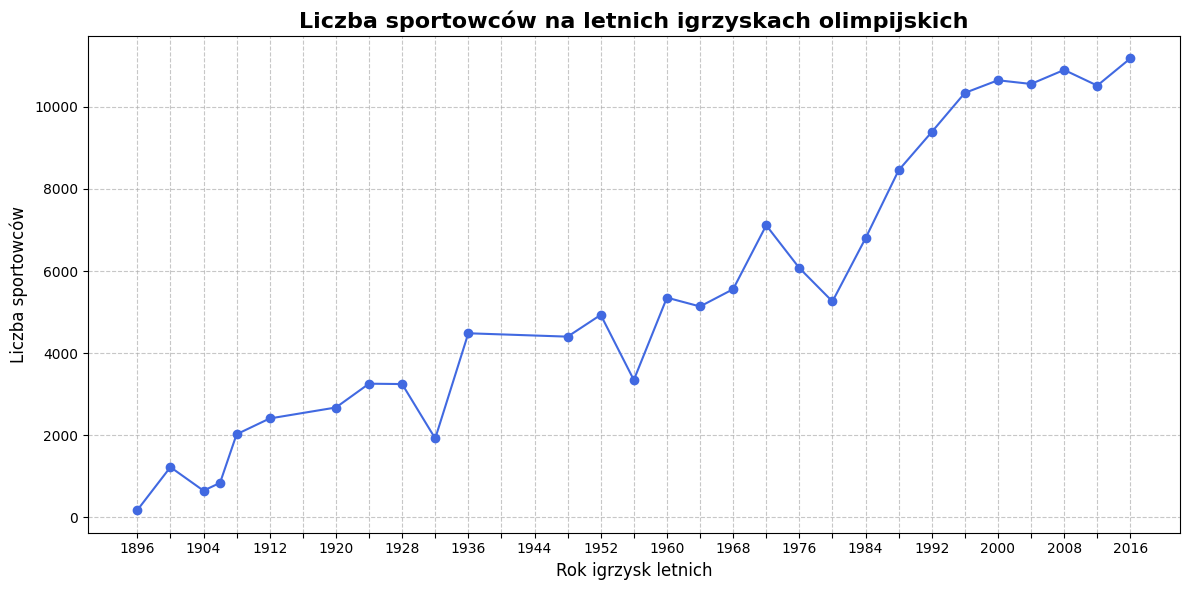

In [12]:
summer = data[data["Season"] == "Summer"]
year_value = summer.drop_duplicates(['Year', 'ID']).groupby('Year').size()
years = year_value.index
value = year_value.values
plt.figure(figsize=(12, 6))
plt.plot(years, value, marker='o', linestyle='-', color='royalblue')
ax = plt.gca()
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
plt.xlabel("Rok igrzysk letnich", fontsize=12)
plt.ylabel("Liczba sportowców", fontsize=12)
ticks = range(min(years), max(years)+1, 4)
labels = [str(y) if y % 8 == 0 else "" for y in ticks]
plt.xticks(ticks=ticks, labels=labels, fontsize=10)
plt.title("Liczba sportowców na letnich igrzyskach olimpijskich", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 11:

Przygotuj na jednym obiekcie `axes` wykres liniowy (`plot`) i wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `color`, `marker`, `markersize`, `linestyle` i `linewidth` oraz dobierz dla nich niestandardowe wartości. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

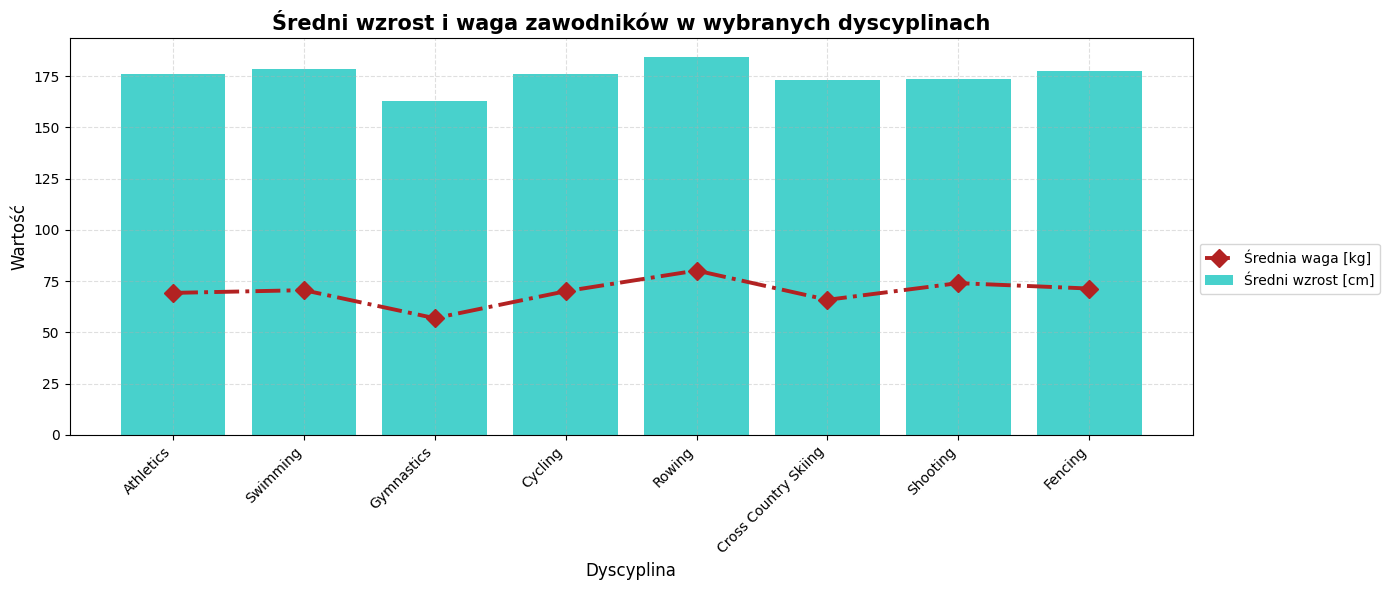

In [13]:
height_weight = data.dropna(subset=["Height", "Weight"])
top_sports = height_weight["Sport"].value_counts().head(8).index
avg_height = height_weight.groupby("Sport")["Height"].mean().reindex(top_sports)
avg_weight = height_weight.groupby("Sport")["Weight"].mean().reindex(top_sports)
sports = top_sports
x = range(len(sports))
plt.figure(figsize=(14, 6))
plt.bar(x, avg_height.values, color='mediumturquoise', label='Średni wzrost [cm]')
plt.plot(x, avg_weight.values, color='firebrick', marker='D', markersize=9, linestyle='-.', linewidth=2.8, label='Średnia waga [kg]')
plt.xticks(x, sports, rotation=45, ha='right')
plt.xlabel("Dyscyplina", fontsize=12)
plt.ylabel("Wartość", fontsize=12)
plt.title("Średni wzrost i waga zawodników w wybranych dyscyplinach", fontsize=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 12:

Przedstaw na jednym obiekcie `axes` wykres liniowy (`plot`) i wykres zamalowujący przestrzeń pomiędzy dwoma horyzontalnymi krzywymi (`fill_between`). Wykorzystaj dane, które sam wybierzesz w sensowny sposób. Na pierwszym wykresie przedstaw średnią wartość, a na drugim wykresie pokaż minimum i maksimum. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

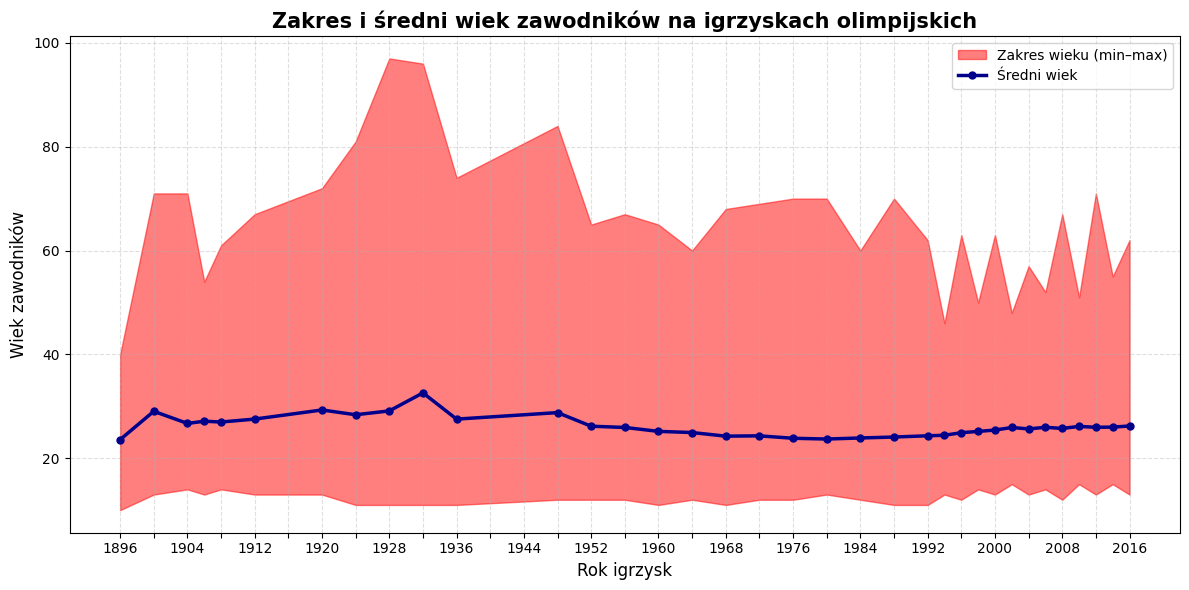

In [14]:
age = data.dropna(subset=["Age"])
age_stats = age.groupby("Year")["Age"].agg(["mean", "min", "max"])
years = age_stats.index
mean_age = age_stats["mean"]
min_age = age_stats["min"]
max_age = age_stats["max"]
plt.figure(figsize=(12, 6))
plt.fill_between(years, min_age, max_age, color='red', alpha=0.5, label='Zakres wieku (min–max)')
plt.plot(years, mean_age, color='darkblue', linewidth=2.5, linestyle='-', marker='o', markersize=5, label='Średni wiek')
plt.xlabel("Rok igrzysk", fontsize=12)
plt.ylabel("Wiek zawodników", fontsize=12)
plt.title("Zakres i średni wiek zawodników na igrzyskach olimpijskich", fontsize=15, weight='bold')
ticks = range(min(years), max(years)+1, 4)
labels = [str(y) if y % 8 == 0 else "" for y in ticks]
plt.xticks(ticks=ticks, labels=labels, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

--------------------
### Wykres bąbelkowy i punktowy

Wykres bąbelkowy rozszerza wykres punktowy o trzecią wartość dla danej serii danych, która jest prezentowana za pomocą rozmiaru znacznika. Przy rosnącej
liczbie zależności, konieczne jest umieszczenie dokładnego opisu wykresu razem z legendą.

##### ⭐ Zadanie 13:

Przygotuj wykres bąbelkowy (`scatter`) opierając się na danych, które sam wybierzesz w sensowny sposób. Wykorzystaj rozmiary i kolory markerów do zaprezentowania większej liczby informacji. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i opis skali koloru). 

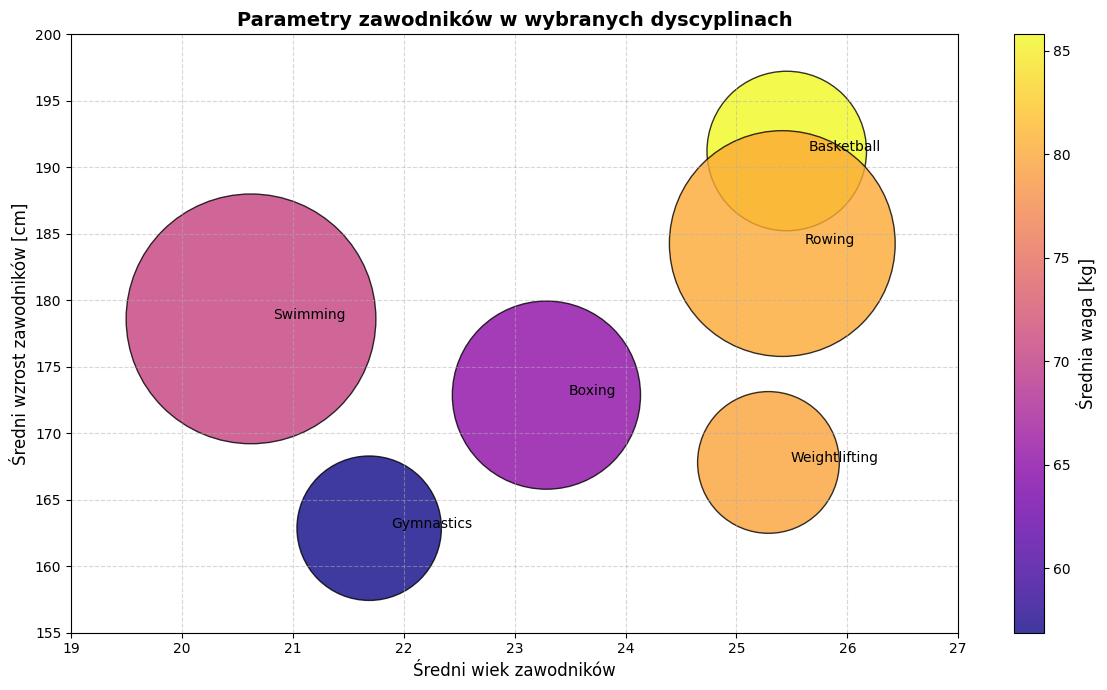

In [15]:
selected_sports = ["Basketball", "Rowing", "Gymnastics", "Swimming", "Boxing", "Weightlifting"]
all_data = data[data["Sport"].isin(selected_sports)].dropna(subset=["Age", "Height", "Weight"])
grouped = all_data.groupby("Sport")
avg_age = grouped["Age"].mean()
avg_height = grouped["Height"].mean()
avg_weight = grouped["Weight"].mean()
athlete_count = grouped["ID"].nunique()
bubble_size = athlete_count * 5
plt.figure(figsize=(12, 7))
scatter = plt.scatter(avg_age, avg_height, s=bubble_size, c=avg_weight, cmap="plasma", alpha=0.8, edgecolors="black")
plt.xlabel("Średni wiek zawodników", fontsize=12)
plt.ylabel("Średni wzrost zawodników [cm]", fontsize=12)
plt.title("Parametry zawodników w wybranych dyscyplinach", fontsize=14, weight="bold")
cbar = plt.colorbar(scatter)
cbar.set_label("Średnia waga [kg]", fontsize=12)
for sport in avg_age.index:
    plt.text(avg_age[sport] + 0.2, avg_height[sport], sport, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(19, 27)
plt.ylim(155, 200)
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 14:

Czy wszystkie informacje z zadania 13 można przedstawić za pomocą wykresu punktowego stworzonego jako wykres liniowy (`plot`) bez linii? Jeżeli tak, wykonaj taki wykres. Jeżeli nie, zdecyduj, które dane są najmniej istotne i zrezygnuj z nich przy wykonywaniu takiego wykresu. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). Do swojego rozwiązania dodaj dowolną animację.

In [24]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

sports = list(avg_age.index)
x = avg_age.values
y = avg_height.values
counts = athlete_count.values

marker_sizes = 6 + (counts - counts.min()) / (counts.max() - counts.min()) * 14

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(19, 27)
ax.set_ylim(155, 200)
ax.set_xlabel("Średni wiek zawodników", fontsize=12)
ax.set_ylabel("Średni wzrost zawodników [cm]", fontsize=12)
ax.set_title("Parametry zawodników w wybranych dyscyplinach", fontsize=14, weight="bold")
ax.grid(True, linestyle="--", alpha=0.5)

points = []
labels = []

def update(frame):
    if frame < len(sports):
        p, = ax.plot(
            x[frame], y[frame],
            linestyle="none",
            marker="o",
            markersize=marker_sizes[frame],
            color="royalblue",
            markeredgecolor="black",
            alpha=0.85
        )
        t = ax.text(x[frame] + 0.15, y[frame], sports[frame], fontsize=10)
        points.append(p)
        labels.append(t)
    return points + labels

ani = FuncAnimation(fig, update, frames=len(sports), interval=500, repeat=False, blit=False)

plt.close(fig)
HTML(ani.to_jshtml())

-------------------
### Mapa ciepła

Mapa ciepła to wizualizacja wielowymiarowa, która wykorzystywana jest do znajdowania wzorców w danych. Dwie kategorie danych umieszczone są w wierszach i kolumnach. Wartości zawarte w macierzy są reprezentowane przez kolory lub nasycenie kolorów, dzięki czemu jawnie odzwierciedlają zależności pomiędzy kategoriami. 

##### ⭐ Zadanie 15:

Przygotuj mapę ciepła (`imshow`, `pcolormesh`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z dwiema metodami rysowania map ciepła i zdecyduj, która będzie lepsza w twoim rozwiązaniu. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i opis skali koloru). 

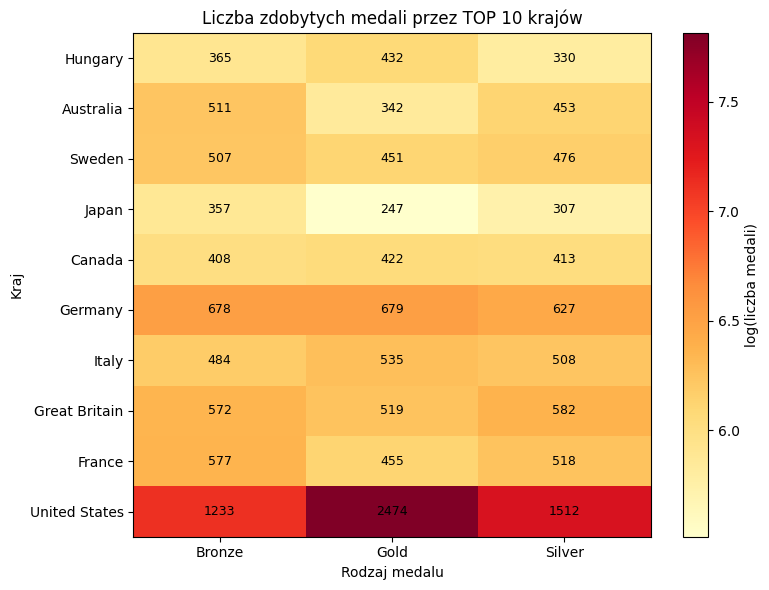

In [27]:
top_teams = data["Team"].value_counts().head(10)

pivot = data[data["Medal"].notna()].pivot_table(
    index="Team",
    columns="Medal",
    values="ID",
    aggfunc="count",
    fill_value=0
).reindex(top_teams.index, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
values = np.log1p(pivot.values)
pc = ax.pcolormesh(values, cmap="YlOrRd")
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_yticks([i + 0.5 for i in range(len(top_teams))])
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        ax.text(j + 0.5, i + 0.5, int(pivot.values[i, j]),
                ha='center', va='center', fontsize=9)

plt.xlabel("Rodzaj medalu")
plt.ylabel("Kraj")
plt.title("Liczba zdobytych medali przez TOP 10 krajów")
cbar = plt.colorbar(pc)
cbar.set_label("log(liczba medali)")
plt.tight_layout()
plt.show()

-------------------
### Wykres radarowy

Wykres radarowy przedstawia wiele zmiennych o tej samej skali w formie pojedynczego wielokąta zamkniętego umieszczonego na okręgu. Wierzchołki figury są ułożone zgodnie z wartościami dla kolejnych kategorii.

##### ⭐ Zadanie 16:

Przygotuj wykres radarowy (`polar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

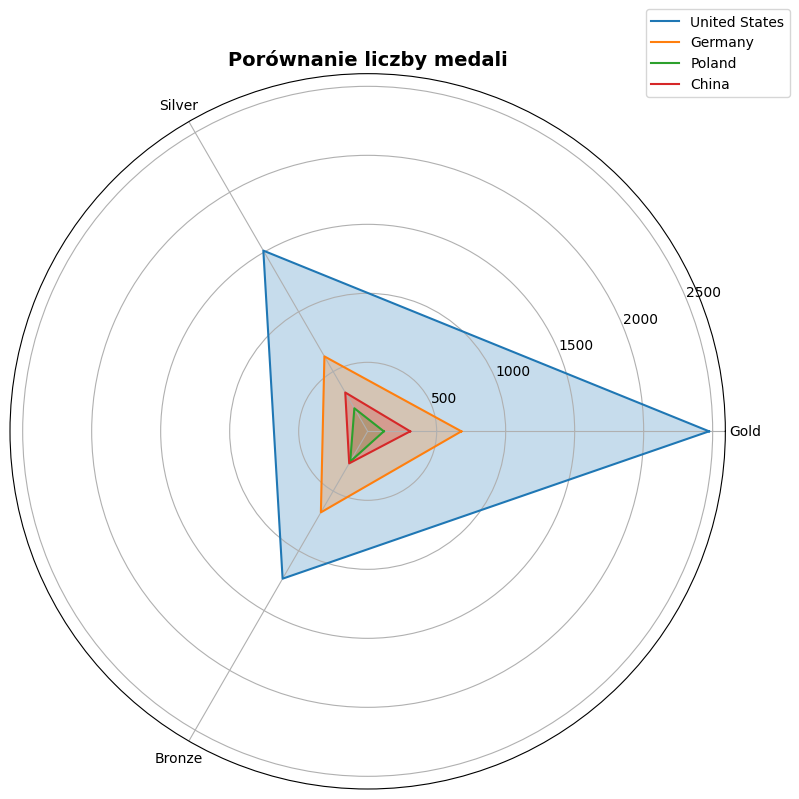

In [23]:
medals = data[data["Medal"].notna()]
countries = ['United States', 'Germany', 'Poland', 'China']
medal_types = ['Gold', 'Silver', 'Bronze']
stats = [[medals[(medals["Team"] == c) & (medals["Medal"] == m)].shape[0] for m in medal_types] for c in countries]
angles = np.linspace(0, 2 * np.pi, len(medal_types), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for i, country in enumerate(countries):
    values = stats[i] + [stats[i][0]]
    ax.plot(angles, values, label=country)
    ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(medal_types)
ax.set_title("Porównanie liczby medali", fontsize=14, weight="bold")
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()